In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [ ]:
import numpy as np
import pandas as pd
from src.features import cycle_day_month
from src._xgboost import search_params
from src.visualization import plot_forecast_with_train
from skforecast.recursive import ForecasterRecursive
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import joblib
import xgboost as xgb
import warnings
from skforecast.exceptions import IgnoredArgumentWarning

warnings.simplefilter('ignore', category=IgnoredArgumentWarning)

C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def process_data(data: pd.DataFrame, start_date: str):
    df = data.copy()
    df = df.asfreq('D')
    df = cycle_day_month(df)
    
    start_date = pd.to_datetime(start_date)
    df['days_from_start'] = (df['Дата'] - start_date).dt.days
    
    df = df.drop(columns=['Дата'])
    
    df = df.interpolate(method='akima').ffill().bfill().round(2)
    
    return df

def show_results(model, df_train_full, df_test, target_col, exog_cols):
    y_pred = model.predict(
                steps=len(df_test),
                exog=df_test[exog_cols]
            )

    rmse = np.sqrt(mean_squared_error(df_test[target_col], y_pred))
    print(f'RMSE на тесте = {rmse}')

    plot_forecast_with_train(df_train_full[target_col], df_test[target_col], y_pred)
    
def fit_best_model(df_train, best_params, target_col, exog_cols):
    best_model = ForecasterRecursive(xgb.XGBRegressor(**best_params, random_state = 42), 
                                    lags = best_params['lags'])
    best_model.fit(
                y=df_train[target_col],
                exog=df_train[exog_cols],
            )
    return best_model

In [4]:
start_date = '2020-11-27'

df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [5]:
df_train_full = process_data(df_train_full, start_date)
df_train = process_data(df_train, start_date)
df_val = process_data(df_val, start_date)
df_test = process_data(df_test, start_date)

Глубина 0

In [6]:
depth = 0
model_path = f'../xgboost/models/xgb_v1_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'День_sin', 'День_cos', 'days_from_start']

In [7]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-12 17:04:26,029] A new study created in memory with name: no-name-4d754906-c757-48c3-93d9-38ecae035516
[I 2026-05-12 17:04:26,219] Trial 0 finished with value: 6.487373341960856 and parameters: {'lags': 5, 'n_estimators': 617, 'learning_rate': 0.10989359040484822, 'max_depth': 4, 'subsample': 0.9890380267663816, 'colsample_bytree': 0.6072812782331639, 'colsample_bylevel': 0.48438591691994026, 'colsample_bynode': 0.8250165278534827, 'reg_alpha': 0.09816704925011084, 'reg_lambda': 0.002866222817678125, 'gamma': 0.29184701353506703, 'min_child_weight': 1, 'max_delta_step': 7}. Best is trial 0 with value: 6.487373341960856.
[I 2026-05-12 17:04:26,336] Trial 1 finished with value: 3.5728629303541446 and parameters: {'lags': 3, 'n_estimators': 205, 'learning_rate': 0.03876670046885554, 'max_depth': 4, 'subsample': 0.6244359203206288, 'colsample_bytree': 0.4342846806204588, 'colsample_bylevel': 0.5017796071761836, 'colsample_bynode': 0.45176583248289065, 'reg_alpha': 4.705068527849

Лучшие параметры = {'lags': 3, 'n_estimators': 205, 'learning_rate': 0.03876670046885554, 'max_depth': 4, 'subsample': 0.6244359203206288, 'colsample_bytree': 0.4342846806204588, 'colsample_bylevel': 0.5017796071761836, 'colsample_bynode': 0.45176583248289065, 'reg_alpha': 4.705068527849723, 'reg_lambda': 4.978115500141908e-05, 'gamma': 0.1067700082348924, 'min_child_weight': 9, 'max_delta_step': 3}
Лучший RMSE score = 3.5728629303541446


In [8]:
best_model = fit_best_model(df_train_full, best_params, target_col, exog_cols)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v1_0']

RMSE на тесте = 3.252794059539672


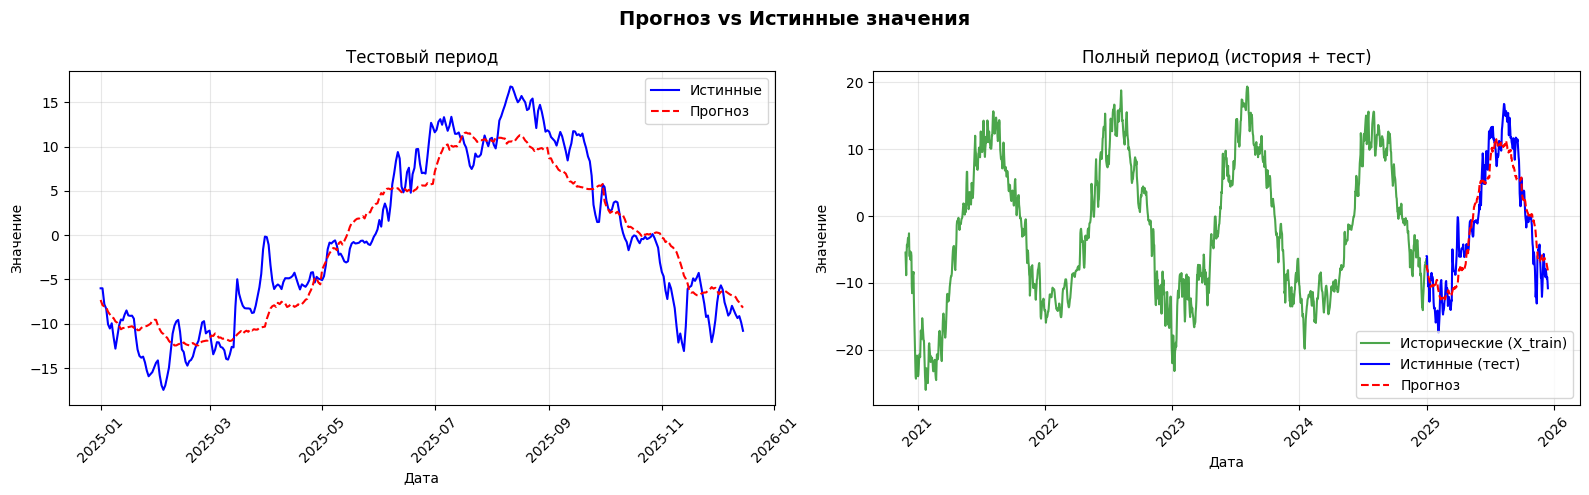

,feature,importance
2,lag_3,0.248671
4,Месяц_cos,0.243580
1,lag_2,0.210016
0,lag_1,0.165414
7,days_from_start,0.077964
3,Месяц_sin,0.045654
5,День_sin,0.005552
6,День_cos,0.003149


In [9]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols)
importances = model.get_feature_importances()
importances

Глубина 5

In [10]:
depth = 5
model_path = f'../xgboost/models/xgb_v1_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'День_sin', 'День_cos', 'days_from_start']

In [11]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-12 17:04:36,092] A new study created in memory with name: no-name-2179fa3b-1103-4a96-8473-ad9391662dc9
[I 2026-05-12 17:04:36,418] Trial 0 finished with value: 1.23579107718252 and parameters: {'lags': 4, 'n_estimators': 387, 'learning_rate': 0.023118196553901425, 'max_depth': 9, 'subsample': 0.5042756354459663, 'colsample_bytree': 0.45074311957723445, 'colsample_bylevel': 0.8938632850198404, 'colsample_bynode': 0.9222811089499983, 'reg_alpha': 2.5767947120037406e-05, 'reg_lambda': 0.161317019337213, 'gamma': 0.0020816333721234335, 'min_child_weight': 3, 'max_delta_step': 6}. Best is trial 0 with value: 1.23579107718252.
[I 2026-05-12 17:04:36,612] Trial 1 finished with value: 1.8592231643355852 and parameters: {'lags': 5, 'n_estimators': 650, 'learning_rate': 0.0036206607485300213, 'max_depth': 1, 'subsample': 0.6267486724068602, 'colsample_bytree': 0.9264529330909165, 'colsample_bylevel': 0.43377763111369566, 'colsample_bynode': 0.8225700710610522, 'reg_alpha': 3.722858860

Лучшие параметры = {'lags': 3, 'n_estimators': 744, 'learning_rate': 0.015523753741668098, 'max_depth': 9, 'subsample': 0.4523690455722861, 'colsample_bytree': 0.7363304139118034, 'colsample_bylevel': 0.8936052006308006, 'colsample_bynode': 0.9084272986601908, 'reg_alpha': 0.06832434772995917, 'reg_lambda': 0.005233656917682364, 'gamma': 0.00021208478542478266, 'min_child_weight': 2, 'max_delta_step': 20}
Лучший RMSE score = 1.2079085223334842


In [12]:
best_model = fit_best_model(df_train_full, best_params, target_col, exog_cols)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v1_5']

RMSE на тесте = 0.5479137549644922


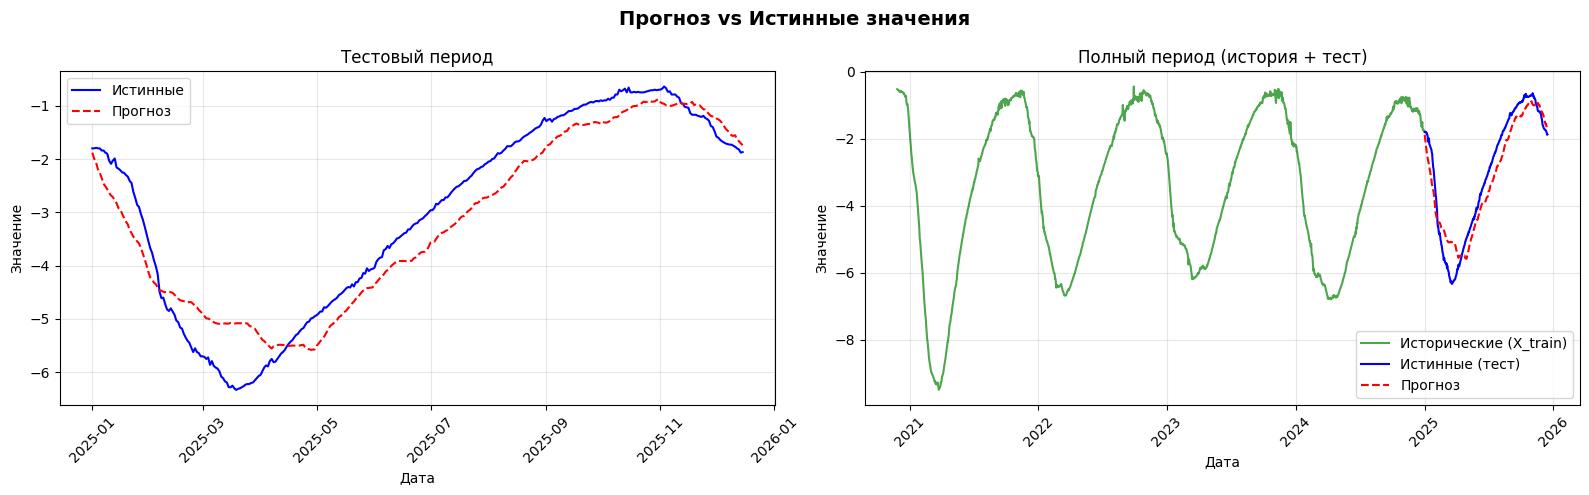

,feature,importance
3,Месяц_sin,0.445495
0,lag_1,0.215255
1,lag_2,0.170704
2,lag_3,0.129291
7,days_from_start,0.024804
4,Месяц_cos,0.013187
6,День_cos,0.000646
5,День_sin,0.000619


In [13]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols)
importances = model.get_feature_importances()
importances

Глубина 10

In [14]:
depth = 10
model_path = f'../xgboost/models/xgb_v1_{depth}'
target_col = f'48-1 ({depth})'
exog_cols = ['Месяц_sin', 'Месяц_cos', 'День_sin', 'День_cos', 'days_from_start']

In [15]:
study = search_params(df_train, df_val, target_col, exog_cols=exog_cols, max_lags=5)
best_params = study.best_params
print(f'Лучшие параметры = {best_params}')
print(f'Лучший RMSE score = {study.best_value}')

[I 2026-05-12 17:04:46,631] A new study created in memory with name: no-name-ab91b953-2268-4321-a665-5aa595302220
[I 2026-05-12 17:04:46,848] Trial 0 finished with value: 0.7490859349010284 and parameters: {'lags': 1, 'n_estimators': 823, 'learning_rate': 0.3430693170066991, 'max_depth': 3, 'subsample': 0.4939557036163804, 'colsample_bytree': 0.42769065481806623, 'colsample_bylevel': 0.8599781631826657, 'colsample_bynode': 0.9673445794889408, 'reg_alpha': 6.17120242426329e-05, 'reg_lambda': 1.5544502623402658e-05, 'gamma': 0.02357725289332053, 'min_child_weight': 13, 'max_delta_step': 0}. Best is trial 0 with value: 0.7490859349010284.
[I 2026-05-12 17:04:46,963] Trial 1 finished with value: 0.40154853215598074 and parameters: {'lags': 1, 'n_estimators': 242, 'learning_rate': 0.19007459075381333, 'max_depth': 3, 'subsample': 0.4936166604846263, 'colsample_bytree': 0.9905445699079988, 'colsample_bylevel': 0.9410905808833416, 'colsample_bynode': 0.9756635924195922, 'reg_alpha': 0.0212425

Лучшие параметры = {'lags': 5, 'n_estimators': 469, 'learning_rate': 0.2789054668378913, 'max_depth': 3, 'subsample': 0.8474417110382845, 'colsample_bytree': 0.4773962567929593, 'colsample_bylevel': 0.9221016160338835, 'colsample_bynode': 0.6967383727142594, 'reg_alpha': 0.00044226006877476516, 'reg_lambda': 0.28010012497401643, 'gamma': 0.0013522738108457074, 'min_child_weight': 5, 'max_delta_step': 4}
Лучший RMSE score = 0.27430874629503676


In [16]:
best_model = fit_best_model(df_train_full, best_params, target_col, exog_cols)
joblib.dump(best_model, model_path)

['../xgboost/models/xgb_v1_10']

RMSE на тесте = 0.44638639303182737


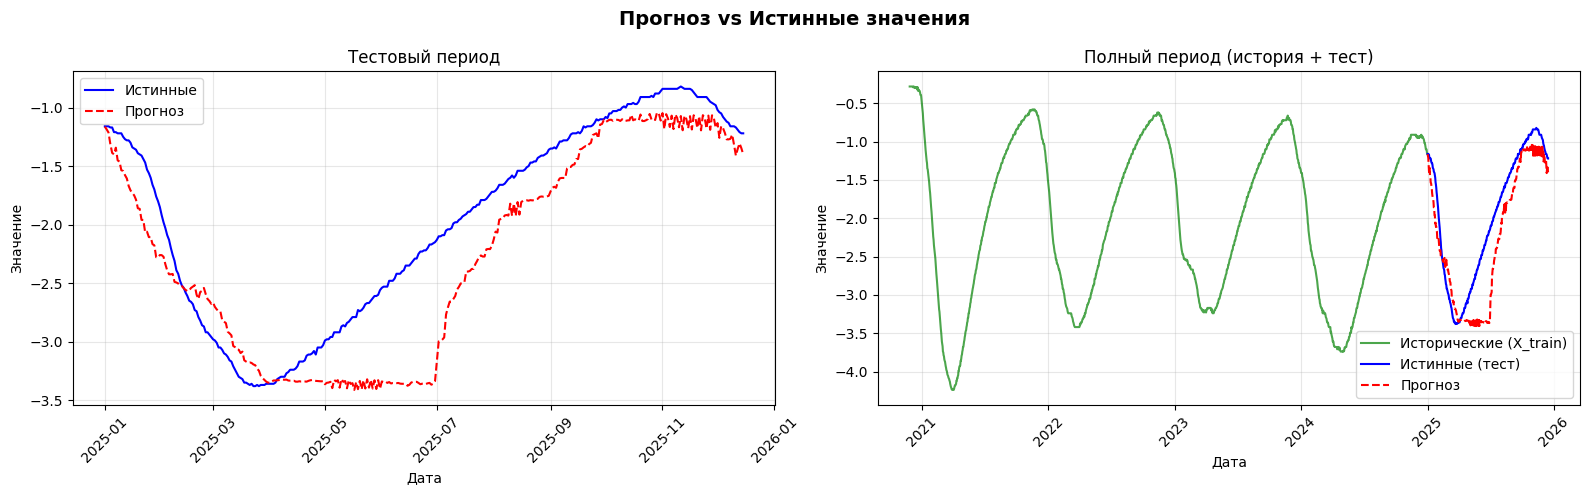

,feature,importance
5,Месяц_sin,0.425095
1,lag_2,0.335933
4,lag_5,0.118693
3,lag_4,0.078221
0,lag_1,0.030527
6,Месяц_cos,0.005812
2,lag_3,0.003392
9,days_from_start,0.001863
7,День_sin,0.000355
8,День_cos,0.000108


In [17]:
model = joblib.load(model_path)
show_results(model, df_train_full, df_test, target_col, exog_cols)
importances = model.get_feature_importances()
importances